In [1]:
import os, numpy as np, pandas as pd, copy, matplotlib.pyplot as plt
import torch, torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
base_path   = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
labels_path = r"C:\Users\Dell\Downloads\congestion_labels.csv"
image_dir   = os.path.join(base_path, "train")

CLASS_NAMES = ['Low', 'Medium', 'High']


In [5]:
vehicle_counts = pd.read_csv(labels_path, dtype={'image_id': str})


In [6]:
subset = vehicle_counts.groupby('congestion_label').sample(n=500, random_state=42)

train_df, temp_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['congestion_label'], random_state=42
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 1050 | Val: 225 | Test: 225


In [7]:

# ── Transforms (same as FGSM for fair comparison) ───────────────────────────
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


In [8]:
# ── Dataset class ───────────────────────────────────────────────────────────
class MIOTCDCongestionDataset(Dataset):
    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = int(row['congestion_label'])
        if self.transform:
            image = self.transform(image)
        return image, label


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 1: LABEL FLIPPING FUNCTION
# Flips High(2) → Low(0) for `poison_rate` fraction of the training set
# This is the most dangerous flip because it makes the model think
# a congested road is completely free-flowing
# ═══════════════════════════════════════════════════════════════════════════

def label_flip_attack(train_df, flip_from=2, flip_to=0, poison_rate=0.20, seed=42):
    """
    Flip labels from one class to another in the training dataframe.

    Args:
        train_df:     training DataFrame with 'congestion_label' column
        flip_from:    source class to flip FROM (default: 2 = High)
        flip_to:      target class to flip TO   (default: 0 = Low)
        poison_rate:  fraction of flip_from samples to corrupt (default: 20%)
        seed:         random seed for reproducibility

    Returns:
        poisoned_df:    poisoned copy of train_df
        flipped_idx:    indices of flipped rows (for audit/logging)
        flip_count:     number of labels actually flipped
    """
    np.random.seed(seed)
    poisoned_df = train_df.copy()

    # Find all rows with the source class
    source_idx = poisoned_df[poisoned_df['congestion_label'] == flip_from].index.tolist()

    # Sample the fraction to flip
    n_flip     = int(len(source_idx) * poison_rate)
    flipped_idx = np.random.choice(source_idx, size=n_flip, replace=False)

    # Flip the labels
    poisoned_df.loc[flipped_idx, 'congestion_label'] = flip_to

    print(f"\n{'='*55}")
    print(f"  LABEL FLIPPING ATTACK")
    print(f"{'='*55}")
    print(f"  Flip direction : {CLASS_NAMES[flip_from]} ({flip_from}) → {CLASS_NAMES[flip_to]} ({flip_to})")
    print(f"  Poison rate    : {poison_rate:.0%}")
    print(f"  Source samples : {len(source_idx)}")
    print(f"  Labels flipped : {n_flip}")
    print(f"{'='*55}")
    print(f"\n  Clean label distribution:")
    print(train_df['congestion_label'].value_counts().to_string())
    print(f"\n  Poisoned label distribution:")
    print(poisoned_df['congestion_label'].value_counts().to_string())

    return poisoned_df, flipped_idx, n_flip


In [10]:

def train_model(train_df, val_ds, test_ds, model_save_path, epochs=10, tag=''):
    """Train a fresh ResNet18 on the given train_df and return test accuracy."""

    # Dataset + balanced sampler
    ds = MIOTCDCongestionDataset(train_df, image_dir, train_transform)

    labels_arr  = train_df['congestion_label'].values
    class_cnts  = np.bincount(labels_arr, minlength=3)
    # Avoid division by zero for empty classes
    class_cnts  = np.where(class_cnts == 0, 1, class_cnts)
    sample_wts  = 1.0 / class_cnts[labels_arr]
    sampler     = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

    train_loader = DataLoader(ds, batch_size=32, sampler=sampler, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Fresh model every time — no contamination between runs
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for name, p in m.named_parameters():
        if any(x in name for x in ['layer3', 'layer4', 'fc']):
            p.requires_grad = True
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(512, 3))
    m    = m.to(device)

    opt  = torch.optim.AdamW([
        {'params': [p for n,p in m.named_parameters()
                    if ('layer3' in n or 'layer4' in n) and p.requires_grad],
         'lr': 1e-4},
        {'params': m.fc.parameters(), 'lr': 1e-3},
    ])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val, best_state = 0.0, None
    history = []

    print(f"\n  Training {tag} model ({epochs} epochs)...")
    for epoch in range(epochs):
        m.train()
        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            opt.zero_grad()
            loss = crit(m(imgs), labs)
            loss.backward()
            opt.step()
        sched.step()

        m.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(device), labs.to(device)
                correct += (m(imgs).argmax(1) == labs).sum().item()
                total   += labs.size(0)
        val_acc = correct / total
        history.append(val_acc)
        print(f"    Epoch {epoch+1:2d} | Val acc = {val_acc:.2%}")

        if val_acc > best_val:
            best_val   = val_acc
            best_state = copy.deepcopy(m.state_dict())

    # Load best weights
    m.load_state_dict(best_state)

    # Test accuracy
    m.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labs in test_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            preds = m(imgs).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labs.cpu().numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_true))
    print(f"\n  ✓ {tag} test accuracy: {test_acc:.2%}")

    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    torch.save(m, model_save_path)
    print(f"  ✓ Saved → {model_save_path}")

    return test_acc, np.array(all_preds), np.array(all_true), history, m



In [11]:

val_ds  = MIOTCDCongestionDataset(val_df,  image_dir, test_transform)
test_ds = MIOTCDCongestionDataset(test_df, image_dir, test_transform)

# --- 3a: Train CLEAN baseline ---
print("\n" + "█"*55)
print("  CLEAN BASELINE (no poisoning)")
print("█"*55)
clean_acc, clean_preds, clean_true, clean_hist, clean_model = train_model(
    train_df, val_ds, test_ds,
    model_save_path='models/clean_baseline.pt',
    epochs=10, tag='CLEAN'
)

# --- 3b: Train POISONED models at 3 poison rates ---
poison_rates  = [0.10, 0.20, 0.40]
poison_results = []

for rate in poison_rates:
    print(f"\n{'█'*55}")
    print(f"  POISONED MODEL — rate = {rate:.0%}")
    print(f"{'█'*55}")

    poisoned_df, flipped_idx, n_flipped = label_flip_attack(
        train_df, flip_from=2, flip_to=0, poison_rate=rate
    )

    p_acc, p_preds, p_true, p_hist, p_model = train_model(
        poisoned_df, val_ds, test_ds,
        model_save_path=f'models/poisoned_{int(rate*100)}pct.pt',
        epochs=10, tag=f'POISONED-{int(rate*100)}%'
    )
    poison_results.append({
        'poison_rate':  rate,
        'n_flipped':    n_flipped,
        'test_acc':     p_acc,
        'acc_drop':     clean_acc - p_acc,
        'preds':        p_preds,
        'true':         p_true,
    })




███████████████████████████████████████████████████████
  CLEAN BASELINE (no poisoning)
███████████████████████████████████████████████████████

  Training CLEAN model (10 epochs)...
    Epoch  1 | Val acc = 52.89%
    Epoch  2 | Val acc = 60.00%
    Epoch  3 | Val acc = 62.67%
    Epoch  4 | Val acc = 60.89%
    Epoch  5 | Val acc = 63.56%
    Epoch  6 | Val acc = 62.22%
    Epoch  7 | Val acc = 66.67%
    Epoch  8 | Val acc = 64.00%
    Epoch  9 | Val acc = 64.89%
    Epoch 10 | Val acc = 64.00%

  ✓ CLEAN test accuracy: 65.78%
  ✓ Saved → models/clean_baseline.pt

███████████████████████████████████████████████████████
  POISONED MODEL — rate = 10%
███████████████████████████████████████████████████████

  LABEL FLIPPING ATTACK
  Flip direction : High (2) → Low (0)
  Poison rate    : 10%
  Source samples : 350
  Labels flipped : 35

  Clean label distribution:
congestion_label
0    350
1    350
2    350

  Poisoned label distribution:
congestion_label
0    385
1    350
2    315

  

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 4: RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════

print("\n\n" + "="*60)
print("  LABEL FLIPPING ATTACK — RESULTS SUMMARY")
print("="*60)
print(f"  {'Model':<30} {'Test Acc':>10} {'Acc Drop':>10}")
print(f"  {'-'*50}")
print(f"  {'Clean baseline':<30} {clean_acc:>10.2%} {'—':>10}")
for r in poison_results:
    label = f"Poisoned {r['poison_rate']:.0%} ({r['n_flipped']} labels flipped)"
    print(f"  {label:<30} {r['test_acc']:>10.2%} {r['acc_drop']:>+10.2%}")
print("="*60)

# Save results CSV
results_df = pd.DataFrame([{
    'model':       'clean_baseline',
    'poison_rate': 0.0,
    'n_flipped':   0,
    'test_acc':    clean_acc,
    'acc_drop':    0.0,
}] + [{
    'model':       f"poisoned_{int(r['poison_rate']*100)}pct",
    'poison_rate': r['poison_rate'],
    'n_flipped':   r['n_flipped'],
    'test_acc':    r['test_acc'],
    'acc_drop':    r['acc_drop'],
} for r in poison_results])

os.makedirs('outputs', exist_ok=True)
results_df.to_csv('outputs/label_flip_results.csv', index=False)
print("\n  Saved → outputs/label_flip_results.csv")




  LABEL FLIPPING ATTACK — RESULTS SUMMARY
  Model                            Test Acc   Acc Drop
  --------------------------------------------------
  Clean baseline                     65.78%          —
  Poisoned 10% (35 labels flipped)     60.00%     +5.78%
  Poisoned 20% (70 labels flipped)     61.33%     +4.44%
  Poisoned 40% (140 labels flipped)     56.89%     +8.89%

  Saved → outputs/label_flip_results.csv


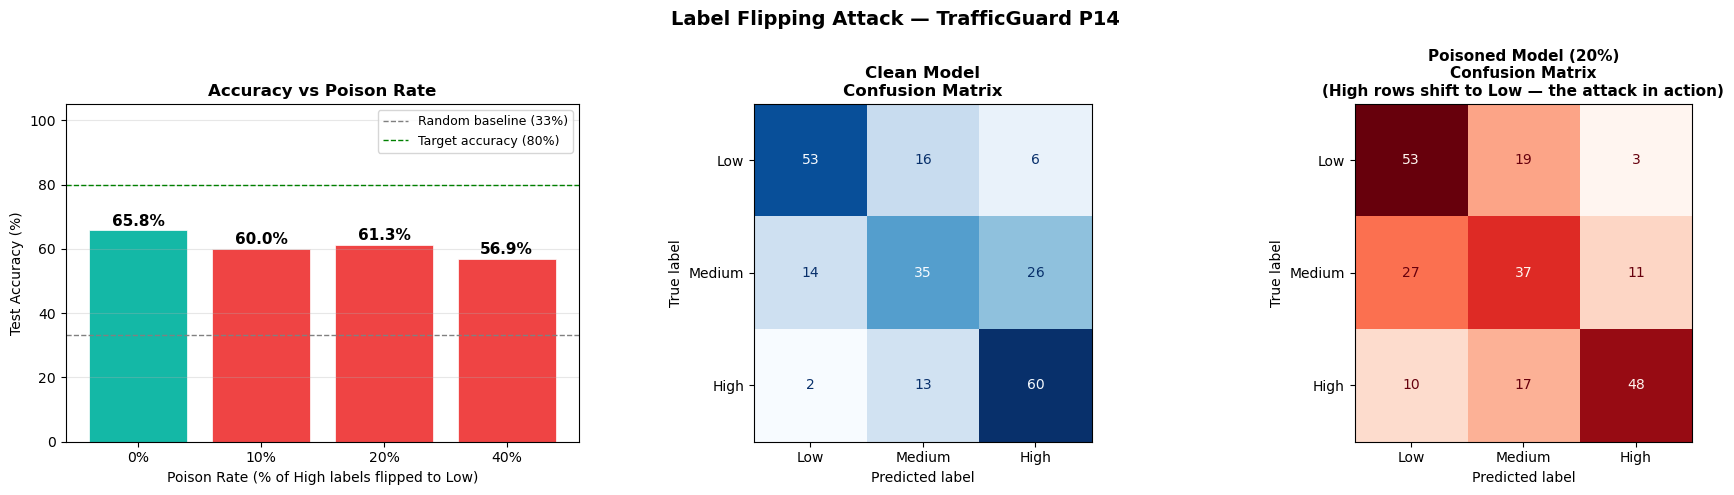


  Saved → outputs/label_flip_results.png


In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Label Flipping Attack — TrafficGuard P14', fontsize=14, fontweight='bold')

# ── Plot 1: Accuracy drop by poison rate ─────────────────────────────────
ax1 = axes[0]
rates_pct = [0] + [int(r['poison_rate']*100) for r in poison_results]
accs      = [clean_acc] + [r['test_acc'] for r in poison_results]
bars = ax1.bar([f'{r}%' for r in rates_pct], [a*100 for a in accs],
               color=['#14B8A6','#EF4444','#EF4444','#EF4444'],
               edgecolor='white', linewidth=0.5)
ax1.axhline(33.3, color='gray', linestyle='--', linewidth=1, label='Random baseline (33%)')
ax1.axhline(80,   color='green', linestyle='--', linewidth=1, label='Target accuracy (80%)')
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xlabel('Poison Rate (% of High labels flipped to Low)', fontsize=10)
ax1.set_ylabel('Test Accuracy (%)', fontsize=10)
ax1.set_title('Accuracy vs Poison Rate', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Confusion matrix — clean model ───────────────────────────────
ax2 = axes[1]
cm_clean = confusion_matrix(clean_true, clean_preds)
disp = ConfusionMatrixDisplay(cm_clean, display_labels=CLASS_NAMES)
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Clean Model\nConfusion Matrix', fontsize=12, fontweight='bold')

# ── Plot 3: Confusion matrix — 20% poisoned model ────────────────────────
ax3 = axes[2]
r20 = next(r for r in poison_results if r['poison_rate'] == 0.20)
cm_poison = confusion_matrix(r20['true'], r20['preds'])
disp2 = ConfusionMatrixDisplay(cm_poison, display_labels=CLASS_NAMES)
disp2.plot(ax=ax3, colorbar=False, cmap='Reds')
ax3.set_title('Poisoned Model (20%)\nConfusion Matrix\n'
              '(High rows shift to Low — the attack in action)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/label_flip_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Saved → outputs/label_flip_results.png")


In [14]:

print("\n" + "="*60)
print("  REPORT FINDINGS")
print("="*60)
print(f"  Clean baseline accuracy         : {clean_acc:.2%}")
for r in poison_results:
    print(f"  Poisoned at {r['poison_rate']:.0%} rate             "
          f": {r['test_acc']:.2%} (drop of {r['acc_drop']:+.2%})")
print()
print("  Attack mechanism:")
print("  • Flipped High(2) → Low(0) labels in training set")
print("  • Images unchanged — only labels corrupted")
print("  • Model learns: congested scenes = Low congestion")
print("  • In production: adaptive signals stay green on busy roads")
print("  • Attack is silent — no visible change to training data")
print("="*60)


  REPORT FINDINGS
  Clean baseline accuracy         : 65.78%
  Poisoned at 10% rate             : 60.00% (drop of +5.78%)
  Poisoned at 20% rate             : 61.33% (drop of +4.44%)
  Poisoned at 40% rate             : 56.89% (drop of +8.89%)

  Attack mechanism:
  • Flipped High(2) → Low(0) labels in training set
  • Images unchanged — only labels corrupted
  • Model learns: congested scenes = Low congestion
  • In production: adaptive signals stay green on busy roads
  • Attack is silent — no visible change to training data
